<a href="https://colab.research.google.com/github/Hamza2058/Exploratory-Data-Analytics/blob/main/EDA_Books_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

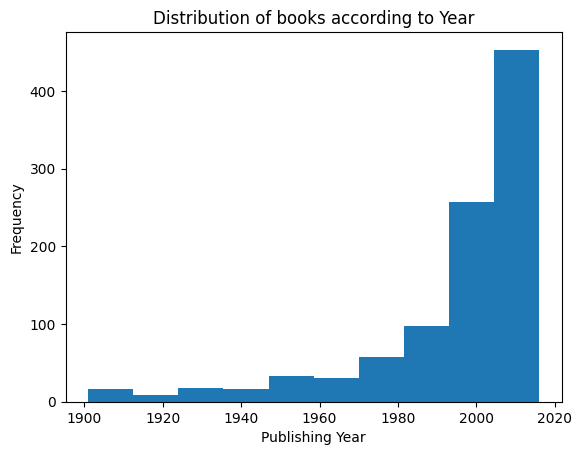

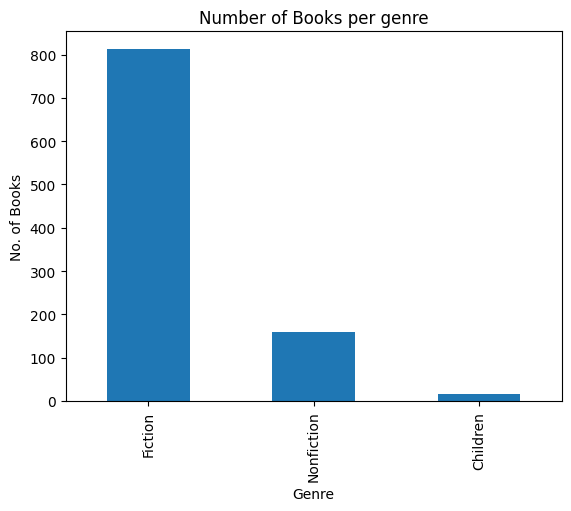

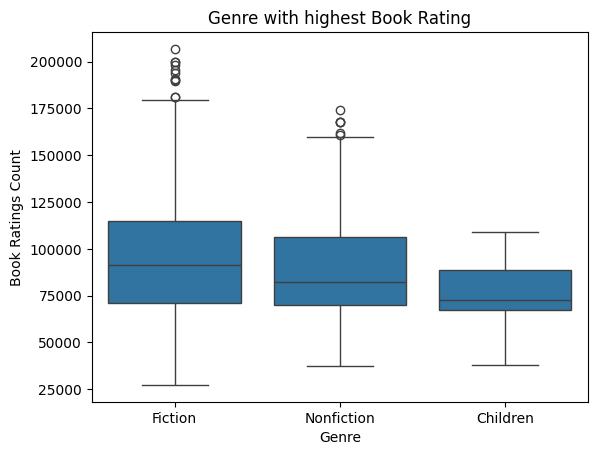

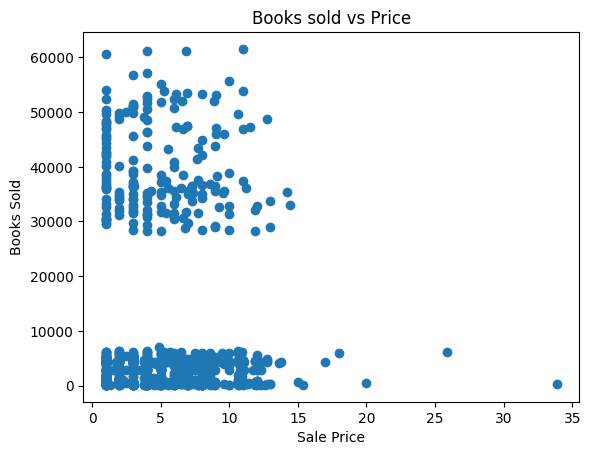

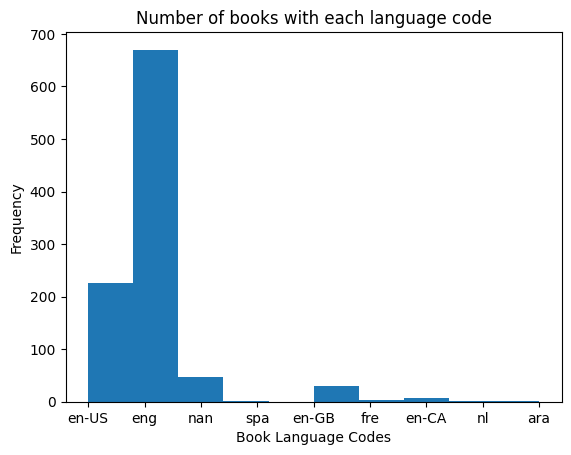

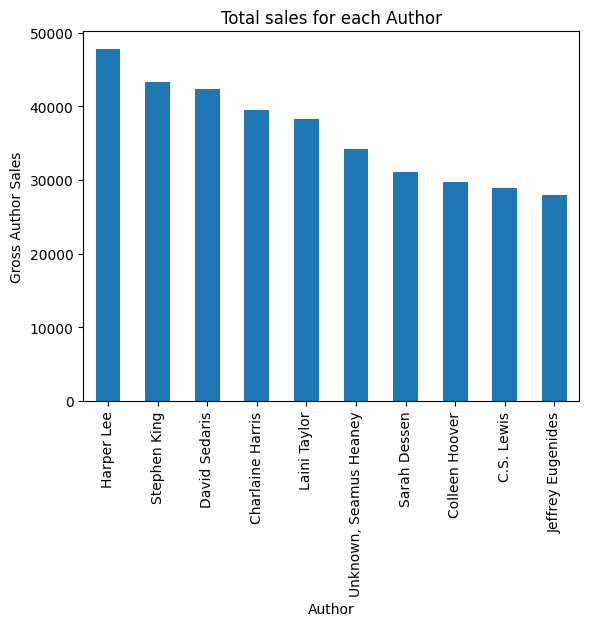

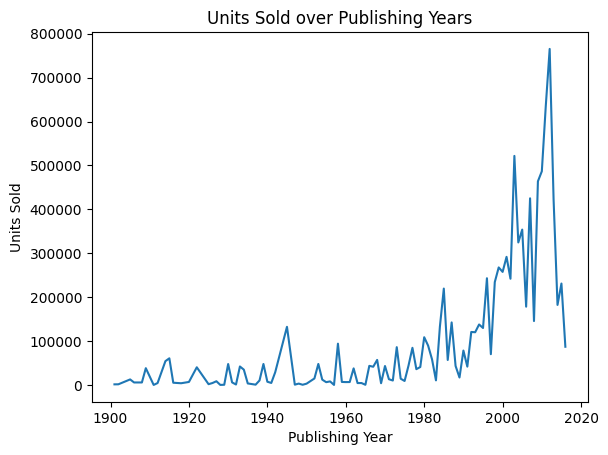

In [31]:
# Essential Python Libraries are imported for cleaning, visualisations etc.
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Essential Data Cleaning begins:

df = pd.read_csv("Books_Data_Clean.csv") # File is imported into Colab and now assigned into a dataframe
df.describe() # Inspecting the dataframe for any outlier, negative or incorrect values

df = df[df["Publishing Year"] > 1900] # Replacing original column values with those above 1900 to fix negative minimum value found during inspection

# df.isna().sum() for books = 21
df = df.dropna(subset="Book Name") # Book Name is the main component of this project hence values cannot be empty and are dropped.

df["Publishing Year"] = df["Publishing Year"].astype(int) # Data type for Publising Year is changed to int from bool as found during inspection.

df["genre"] = df["genre"].str.strip().str.title() # "genre" column is formatted to fix presentation and enhance appearance.
df["genre"] = df["genre"].str.split().str[-1] # Repeating words in the string values like "genre fiction" were formatted to "Fiction" to improve readability.

# Exploratory Data Analysis begins:
plt.hist(df["Publishing Year"]) # Making a histogram of the Publishing Year with the most amount of Books, shows us how old the mean book age is
plt.xlabel("Publishing Year") # X-axis title
plt.ylabel("Frequency") # Y-axis title
plt.title("Distribution of books according to Year") # Relevant title of the histogram
plt.show() # Statement used to print any plot, used after the main code

df["genre"].value_counts().plot(kind = "bar") # Making a barchart to visualise the amount of Books each genre has, useful for spread and discrimination
plt.xlabel("Genre") # X-axis title
plt.ylabel("No. of Books") # Y-axis title
plt.title("Number of Books per genre") # Relevant title of the barchart
plt.show() # Statement used to print any plot, used after the main code

sns.boxplot(x = "genre", y = "Book_ratings_count", data = df) # Boxplot of the Genre with the highest Book Rating, useful to know how in demand or famous a set genre is.
plt.xlabel("Genre") # X-axis title
plt.ylabel("Book Ratings Count") # Y-axis title
plt.title("Genre with highest Book Rating") # Relevant title of the boxplot
plt.show() # Statement used to print any plot, used after the main code

plt.scatter(df["sale price"], df["units sold"]) # Scatter diagram of the amount of Books sold at each price, useful to gather total revenue, mean purchase price etc.
plt.xlabel("Sale Price") # X-axis title
plt.ylabel("Books Sold") # Y-axis title
plt.title("Books sold vs Price") # Relevant title of the scatter diagram
plt.show() # Statement used to print any plot, used after the main code

df["language_code"] = df['language_code'].astype(str) # converting language code into str data type so it can be used to plot histogram
plt.hist(df["language_code"]) # Making a histogram to show the language in which most of the books are written, useful to know which language is spoken and widely understood.
plt.xlabel("Book Language Codes") # X-axis title
plt.ylabel("Frequency") # Y-axis title
plt.title("Number of books with each language code") # Relevant title of the histogram
plt.show() # Statement used to print any plot, used after the main code

gross_author_sales = df.groupby("Author")["gross sales"].sum().sort_values(ascending=False).head(10).plot(kind = "bar") # Bar chart of the Author with the most amount of copies sold, useful to know most famous author etc.
plt.xlabel("Author") # X-axis title
plt.ylabel("Gross Author Sales") # Y-axis title
plt.title("Total sales for each Author") # Relevant title of the barchart
plt.show() # Statement used to print any plot, used after the main code

df.groupby("Publishing Year")["units sold"].sum().plot(kind = "line") # Line plot used to show in which Publishing Year were the most amount of books sold, useful to know whether recent books or older ones are in demand.
plt.xlabel("Publishing Year") # X-axis title
plt.ylabel("Units Sold") # Y-axis title
plt.title("Units Sold over Publishing Years") # Relevant title of the line plot
plt.show() # Statement used to print any plot, used after the main code
















Publishing Year Distribution

The histogram shows that most books in the dataset were published in recent decades, with fewer titles from earlier years. The distribution is slightly right-skewed, indicating a higher concentration of modern publications. This suggests that the dataset is dominated by relatively recent books.

Genre Distribution

The bar chart reveals that some genres have significantly more books than others, indicating uneven representation across genres. This suggests that certain genres are more popular or more frequently published, while others cater to niche audiences.

Book Ratings by Genre

The boxplot highlights noticeable differences in book rating counts across genres. Some genres show higher median ratings and greater variability, indicating stronger reader engagement. The presence of outliers suggests that a few books achieve exceptionally high popularity within their genre.

Sale Price vs Units Sold

The scatter plot indicates a general negative relationship between sale price and units sold. Lower-priced books tend to sell in higher volumes, while higher-priced books usually sell fewer units. However, some higher-priced books still perform well, suggesting the influence of factors such as author reputation or demand.

Language Distribution

The language code histogram shows that most books are published in a small number of dominant languages. This suggests that the dataset primarily targets widely spoken languages, with limited representation from niche language markets.